In [25]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. Libraries imported successfully!")

Setup complete. Libraries imported successfully!


In [26]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_wine

# Load the Wine dataset and scale features
wine = load_wine()
X_raw = wine.data.astype("float32")
y = wine.target

# Standardize features for better neural network convergence
mean = X_raw.mean(axis=0)
std = X_raw.std(axis=0)
X = (X_raw - mean) / std

y_one_hot = tf.keras.utils.to_categorical(y, num_classes=3)

print("Shape of X:", X.shape)
print("Class counts:", np.bincount(y))
print("Feature names:", wine.feature_names)

Shape of X: (178, 13)
Class counts: [59 71 48]
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


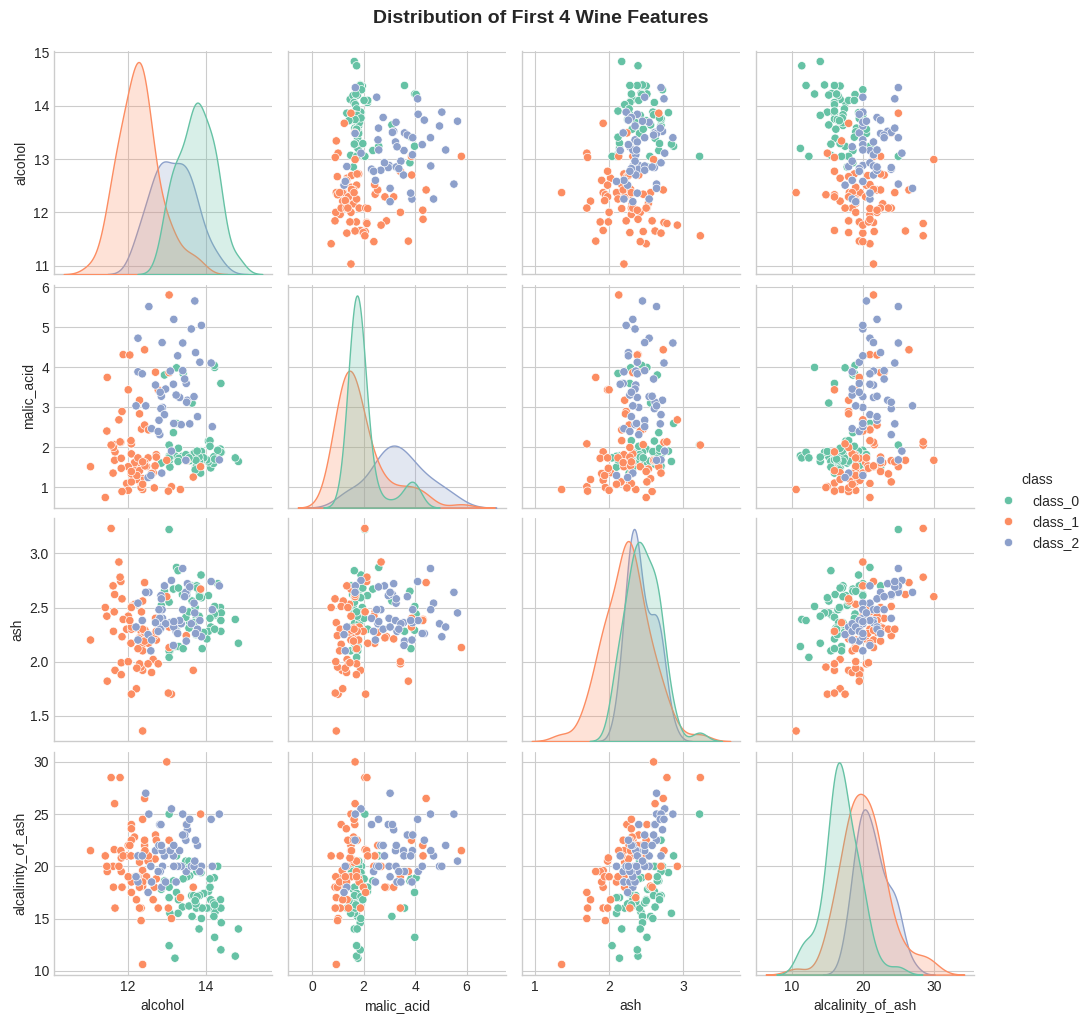

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distributions of the first four features
df_vis = pd.DataFrame(X_raw[:, :4], columns=wine.feature_names[:4])
df_vis["class"] = [wine.target_names[i] for i in y]

sns.pairplot(df_vis, hue="class", palette="Set2")
plt.suptitle("Distribution of First 4 Wine Features", y=1.02, fontsize=14, fontweight="bold")
plt.show()

In [28]:
from sklearn.model_selection import train_test_split

# Train / Validation / Test Split
X_train_full, X_test, y_train_full, y_test, y_train_full_int, y_test_int = train_test_split(
    X, y_one_hot, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_train, X_val, y_train, y_val, y_train_int, y_val_int = train_test_split(
    X_train_full, y_train_full, y_train_full_int,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full_int,
)

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

Train shape     : (113, 13)
Validation shape: (29, 13)
Test shape      : (36, 13)


In [29]:
import tensorflow as tf

# Build the Feedforward Neural Network with modified layer values
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(13,)), # 13 input features
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"), # 3 output classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,243 (40.01 KB)

 Trainable params: 10,243 (40.01 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
import tensorflow as tf

# Train the Network with modified batch size and early stopping parameters
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
)

print(f"Training finished after {len(history.history['loss'])} epochs.")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7611 - loss: 0.8028 - val_accuracy: 0.9655 - val_loss: 0.4971
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.3478 - val_accuracy: 0.9655 - val_loss: 0.2395
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9912 - loss: 0.1599 - val_accuracy: 0.9655 - val_loss: 0.1247
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9912 - loss: 0.0749 - val_accuracy: 0.9655 - val_loss: 0.0819
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9912 - loss: 0.0420 - val_accuracy: 0.9655 - val_loss: 0.0644
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9912 - loss: 0.0392 - val_accuracy: 0.9655 - val_loss: 0.0602
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 0.9655 - val_loss: 0.0620
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 0.9655 - val_loss: 0.0658


In [31]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Evaluate on the Test Set
test_probabilities = model.predict(X_test, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_true = np.argmax(y_test, axis=1)

test_accuracy = accuracy_score(test_true, test_predictions)
print(f"Test Accuracy : {test_accuracy:.4f}\n")
print(classification_report(test_true, test_predictions, target_names=wine.target_names))

Test Accuracy : 0.9722

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



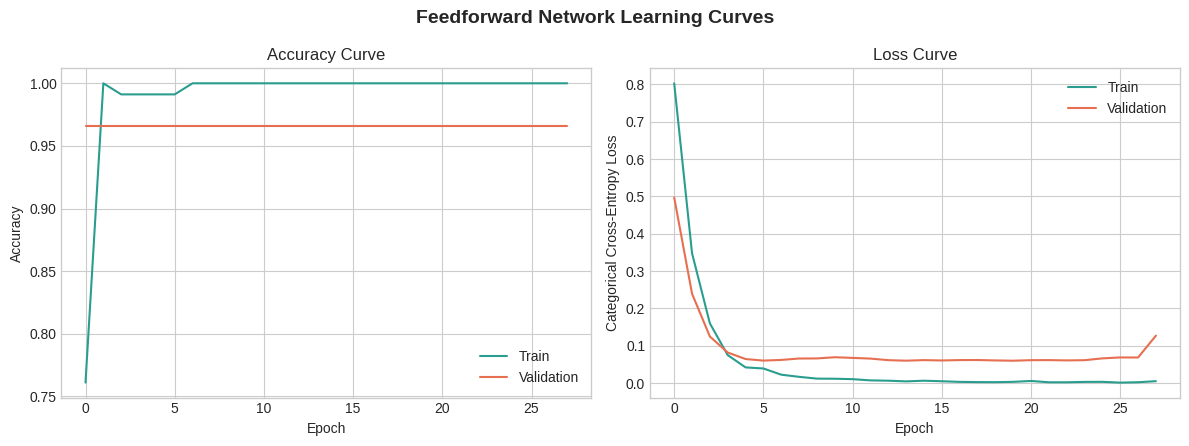

In [32]:
import matplotlib.pyplot as plt

# Training vs Validation Accuracy and Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0].set_title("Accuracy Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train", color="#2a9d8f")
axes[1].plot(history.history["val_loss"], label="Validation", color="#e76f51")
axes[1].set_title("Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Categorical Cross-Entropy Loss")
axes[1].legend()

plt.suptitle("Feedforward Network Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

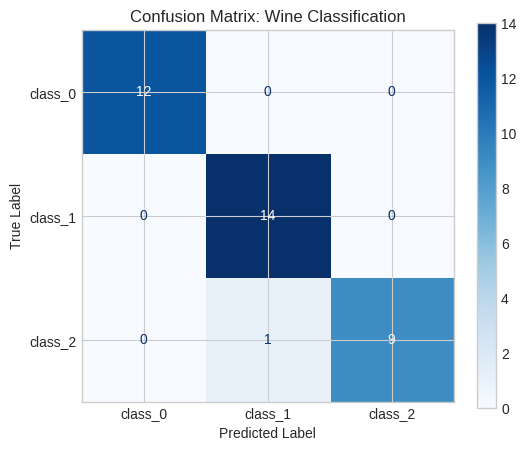

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Wine dataset
cm = confusion_matrix(test_true, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")

plt.title("Confusion Matrix: Wine Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

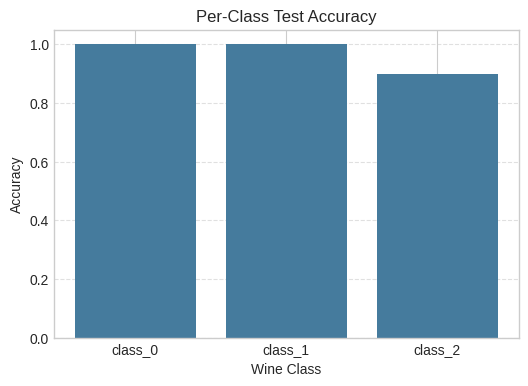

In [34]:
import matplotlib.pyplot as plt

# Per-Class Accuracy calculation
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(6, 4))
plt.bar(wine.target_names, per_class_accuracy, color="#457b9d")

plt.xlabel("Wine Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Test Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [35]:
import pandas as pd

# Preview predictions vs ground truth in a structured dataframe
pred_df = pd.DataFrame({
    "Actual Class": [wine.target_names[i] for i in test_true],
    "Predicted Class": [wine.target_names[i] for i in test_predictions],
    "Correct": test_true == test_predictions
})

display(pred_df.head(15))

,Actual Class,Predicted Class,Correct
0,class_0,class_0,True
1,class_2,class_1,False
2,class_0,class_0,True
3,class_1,class_1,True
4,class_1,class_1,True
5,class_0,class_0,True
6,class_0,class_0,True
7,class_1,class_1,True
8,class_1,class_1,True
9,class_2,class_2,True
